In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
import fly_plot_lib.plot as fpl

import scipy.stats

/opt/anaconda3/envs/Python311/lib/python3.11/site-packages/figurefirst/mpl_fig_to_figurefirst_svg.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
import unifying_algo_analysis_helper as uaah
from set_zorder_functions import *

In [7]:
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

In [9]:
MARKERSIZE = 0.75
MODEL_LINE_COLOR = 'none'
TRANSLATION = True

In [11]:
FIGURE_NAME = 'supplemental_unifying_analysis.svg'

In [49]:
class LabelToMetadata:
    def __init__(self):
 
        self.flash = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/laminar_data_flash_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/unsteady_top_on_data_flash_translation' + str(TRANSLATION) + '.parquet': [2, '#2b75b3b3', 'unsteady'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/stillair_data_flash_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                               }
   
        self.sham = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/laminar_data_sham_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/unsteady_top_on_data_sham_translation' + str(TRANSLATION) + '.parquet': [2, '#2b75b3b3', 'unsteady'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/stillair_data_sham_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                               }

        self.WT_flash = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/WT_laminar_data_flash_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 'None': [2, '#2b75b3b3', 'unsteady'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/WT_stillair_data_flash_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                               }
        
        self.WT_sham = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/WT_laminar_data_sham_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 'None': [2, '#2b75b3b3', 'unsteady'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/WT_stillair_data_sham_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                               }
        
        self.CFD_casting = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/cfd_sim_steady_casting_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/cfd_sim_unsteady_casting_translation' + str(TRANSLATION) + '.parquet': [2, '#2b75b3b3', 'unsteady'], 
                                 'None': [3, '#084a72ff', 'stillair'], 
                               }
        
        self.CFD_circling = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/cfd_sim_steady_circling_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                                 'None': [2, '#2b75b3b3', 'unsteady'], 
                                 '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/cfd_sim_still_air_circle_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                               }
        
        self.unifying = metadata = {'../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/new_unifying_laminar_translation' + str(TRANSLATION) + '.parquet': [1, '#991128ff', 'laminar'], 
                         '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/new_unifying_unsteady_translation' + str(TRANSLATION) + '.parquet': [2, '#2b75b3b3', 'unsteady'], 
                         '../../../../Data/Unifying_Algo_Results/Supplemental/generate_supplementary_figure/unifying_algo_results/new_unifying_stillair_translation' + str(TRANSLATION) + '.parquet': [3, '#084a72ff', 'stillair'], 
                       }
        

In [53]:
label = 'sham'
label_to_metadata = LabelToMetadata()
fifi_label_stats = label + '_' + 'stats'
metadata = label_to_metadata.__getattribute__(label)

In [55]:
def get_median_slope_and_axis_ratio(fname):
    df = pd.read_parquet(fname)

    slopes = []
    axis_ratios = []
    rotation = []

    for obj_id in df.obj_id_unique_event.unique():
        data = df[df.obj_id_unique_event==obj_id].copy()
        #slopes.append(data.slope.abs().median())

        data['slope_abs'] = data.slope.abs()
        slopes.append( uaa.get_weighted_value(data, col='slope_abs', use='rmse_affine') )

        axis_ratios.append( uaa.get_weighted_value(data, col='axis_ratio', use='rmse_affine') )

        data.rotation = data.rotation.abs()
        rotation.append( uaa.get_weighted_value(data, col='rotation', use='rmse_affine') )

            
    results = {'slopes': np.array(slopes)/0.01,
               'axis_ratios': np.array(axis_ratios),
               'rotation': np.array(rotation),
               #'percent_affine_improvements': np.array(percent_affine_improvements),
              }
    
    return results

In [57]:
layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

median slope:  2.586081872524349


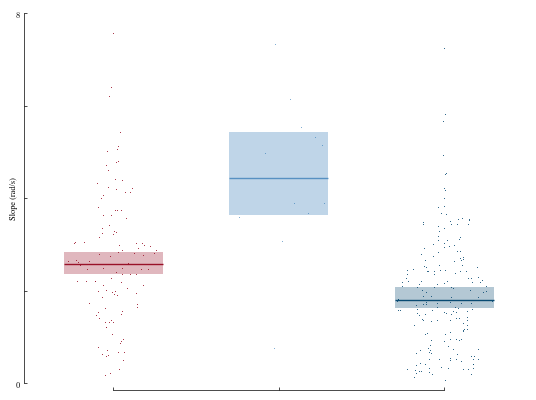

In [61]:
#ax = layout.axes[(fifi_label_stats, 'slopes')]
fig,ax = plt.subplots()
feature = 'slopes'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []
dpoints = []
for key, val in metadata.items():
    if key == 'None':
        continue
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)
    dpoints.append(results[feature])
    if xix<=3:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

print('median slope: ', np.median(y_data_for_regression))
median_slope = np.median(y_data_for_regression)
xixs = [1,2,3]
ax.hlines([median_slope,],
          xixs[0]-0.5, xixs[-1]+0.5, 
          linestyles=['--',], colors=[MODEL_LINE_COLOR,])

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,8)

ax.set_ylabel('Slope (rad/s)', labelpad=-2)


ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.set_yticks([0, 2, 4, 6, 8])
ax.set_yticklabels(['$0$', '', '', '', '$8$'])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)

# data = diagnose_axis_elements(ax, verbose=True)
set_selective_rasterization(ax, rasterize_markers=['o'])

#ax.set_rasterization_zorder(1000)

In [63]:
scipy.stats.kruskal(dpoints[0], dpoints[1],dpoints[2])

KruskalResult(statistic=np.float64(41.23266447112189), pvalue=np.float64(1.1128603596400453e-09))

In [12]:
ax = layout.axes[(fifi_label_stats, 'axis_ratios')]

feature = 'axis_ratios'

x_data_for_regression = []
y_data_for_regression = []

ticks = []
ticklabels = []
for key, val in metadata.items():
    if key == 'None':
        continue
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)

    if xix<=3:
        x_data_for_regression.append(xix)
        y_data_for_regression.append(np.median(results[feature]))

result = scipy.stats.linregress(x_data_for_regression, y_data_for_regression)
axis_ratio_slope = result.slope
axis_ratio_intercept = result.intercept
x = np.linspace(x_data_for_regression[0]-0.5, x_data_for_regression[-1]+0.5, 10)
y = x*axis_ratio_slope + axis_ratio_intercept
ax.plot(x, y, '--', color=MODEL_LINE_COLOR)

print('axis ratios')
print(x_data_for_regression)
print(y_data_for_regression)

model_axis_ratio = {}
for key, val in metadata.items():
    if key == 'None':
        continue
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val
    model_axis_ratio_for_condition = xix*axis_ratio_slope + axis_ratio_intercept
    model_axis_ratio.setdefault(fname, model_axis_ratio_for_condition)

print('axis_ratio_slope: ', axis_ratio_slope)
print('axis_ratio_intercept: ', axis_ratio_intercept)

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,1)

ax.set_ylabel('Axis ratio', labelpad=-2)

ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['$0$', '', '', '', '', '$1$'])

ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)
set_selective_rasterization(ax, rasterize_markers=['o'])

axis ratios
[1, 2, 3]
[0.15586583394542886, 0.729932474792673, 0.8769819891331958]
axis_ratio_slope:  0.3605580775938835
axis_ratio_intercept:  -0.1335227225640011


In [13]:
ax = layout.axes[(fifi_label_stats, 'rotations')]

feature = 'rotation'

ticks = []
ticklabels = []
for key, val in metadata.items():
    if key == 'None':
        continue
    fname = key
    results = get_median_slope_and_axis_ratio(fname)
    xix, color, label = val

    ticks.append(xix)
    ticklabels.append(label)
    
    hist_counts, hist_bins = np.histogram(results[feature], bins=20)
    fpl.scatter_box_violin_distribution(ax, xix, copy.copy(results[feature]), hist_counts, hist_bins, color=color, markersize=MARKERSIZE)



ax.set_xlim(0.5, 3.5)
ax.set_ylim(0,np.pi)

ax.set_ylabel('Rotation angle', labelpad=-2)

ax.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_yticklabels(['$0$', '', '', '', '$\pi$'])

ax.set_xticks(ticks)
ax.set_xticklabels([])

ax.tick_params(axis='y', pad=2)

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                 tick_length=2.5,
                                 spine_locations={'left': 5, 'bottom': 5},
                                 linewidth=0.5)
fifi.mpl_functions.set_fontsize(ax, 6)
set_selective_rasterization(ax, rasterize_markers=['o'])

In [14]:
layout.append_figure_to_layer(layout.figures[fifi_label_stats], fifi_label_stats, cleartarget=True)
layout.write_svg(FIGURE_NAME)